Loading data from DuckDB...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Data loaded successfully! Total records: 2,000,000
Date range: 2022-01-01 06:05:24.463000 to 2025-04-30 22:01:18.353000

🌾 KISAN CALL CENTRE (KCC) ANALYTICS DASHBOARD 🌾

📊 KEY METRICS
----------------------------------------
          Metric                    Value
   Total Queries                2,000,000
  States Covered                       38
Query Categories                       22
         Sectors                        4
      Date Range 2022-01-01 to 2025-04-30

📈 QUERIES OVER TIME
----------------------------------------


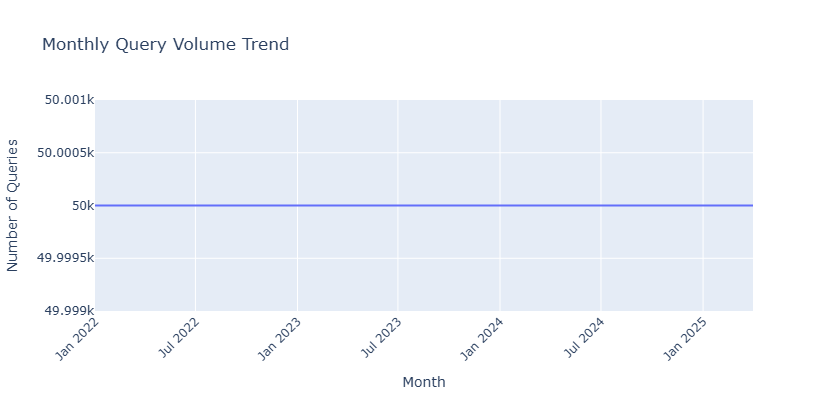

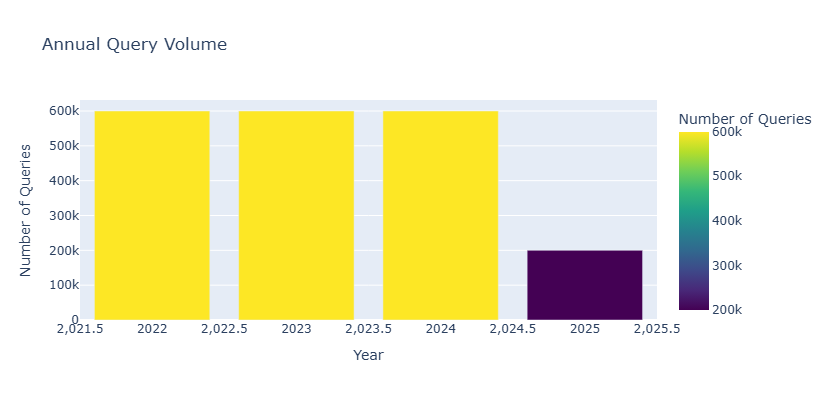


🗺️ GEOGRAPHIC DISTRIBUTION
----------------------------------------


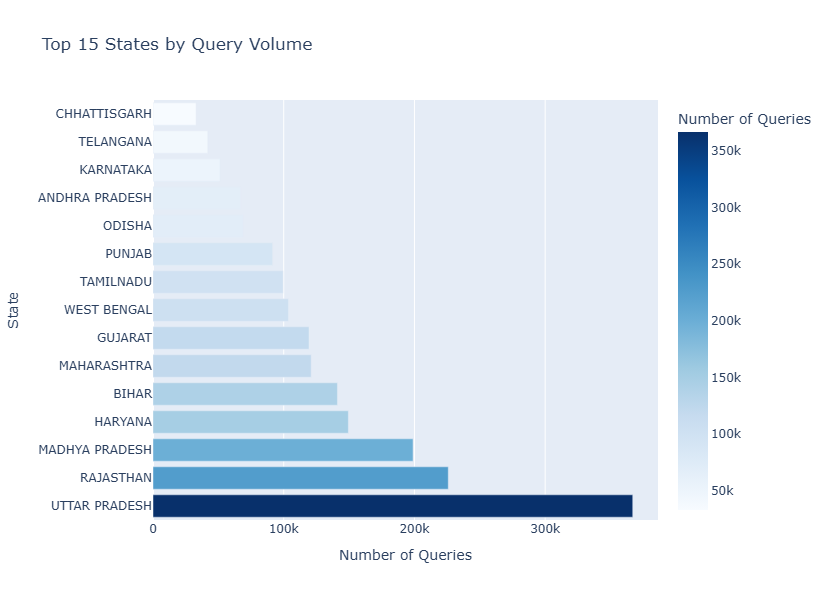


📋 QUERY CATEGORIES
----------------------------------------


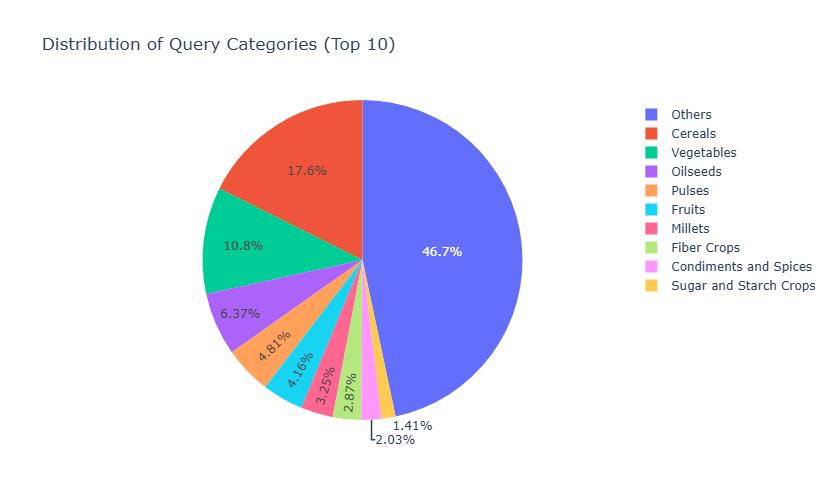


🏭 SECTOR ANALYSIS
----------------------------------------


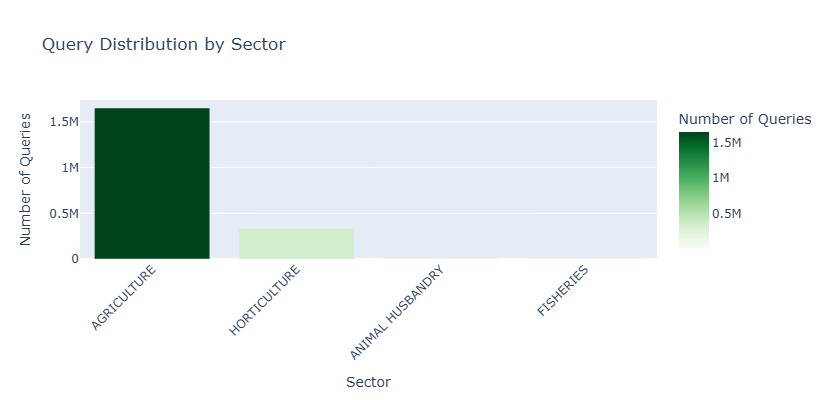


🌱 CROP ANALYSIS
----------------------------------------


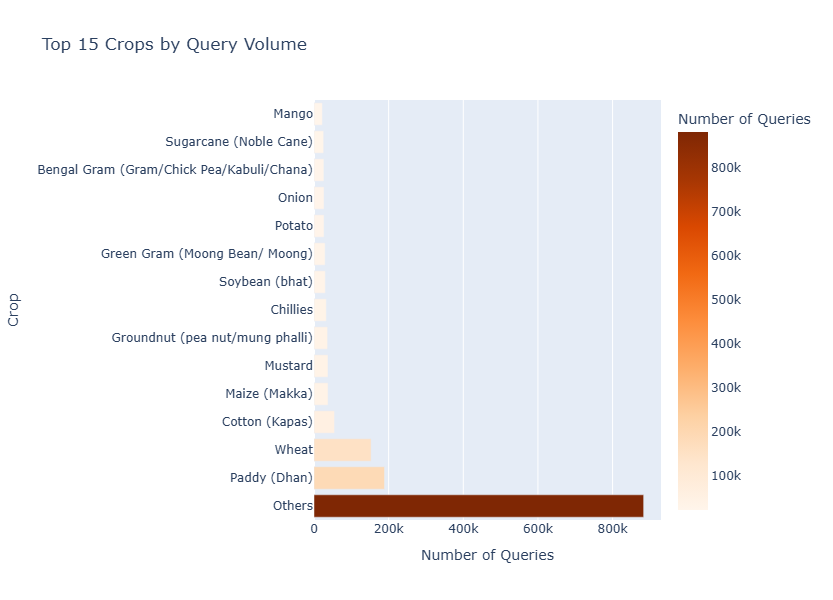


🔥 STATE vs CATEGORY HEATMAP
----------------------------------------


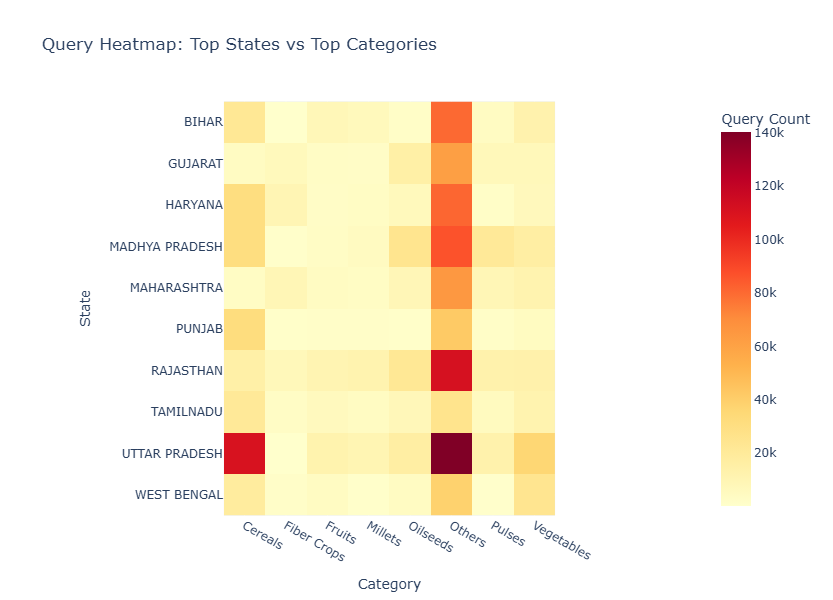


🌤️ SEASONAL PATTERNS
----------------------------------------


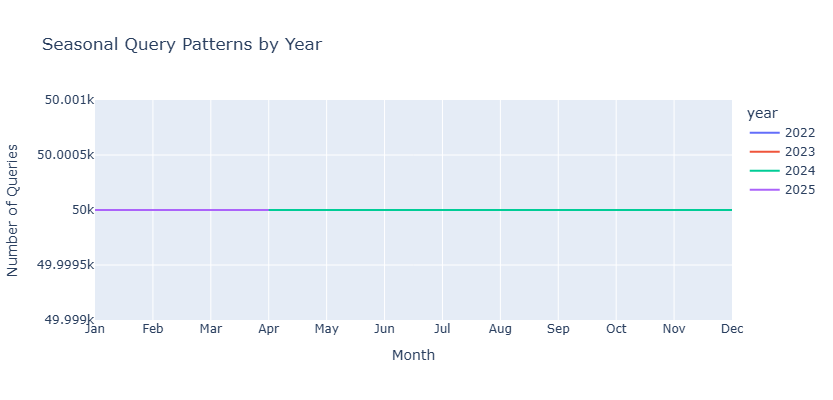


📊 SUMMARY STATISTICS
----------------------------------------
                Dimension                   Value
            Total Queries               2,000,000
Average Queries per State                   52632
        Most Active State UTTAR PRADESH (367,000)
             Top Category        Others (902,772)
               Top Sector AGRICULTURE (1,652,674)
        Most Queried Crop        Others (883,259)

📋 DASHBOARD COMPLETE - Data insights generated successfully!

🎛️ INTERACTIVE FILTERS
----------------------------------------
Use the dropdowns below to filter the data:


Output()


✅ Database connection closed successfully.


In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Connect to database and load data
print("Loading data from DuckDB...")
con = duckdb.connect('/app/storage/processed_data/kcc_queries_processed.duckdb')

# Load fact queries from 2022 onwards
fact = con.execute("""
    SELECT * FROM fct_queries
    WHERE created_on >= '2022-01-01'
""").df()

# Load dimension tables
dim_demography = con.execute("SELECT * FROM dim_demography").df()
dim_category = con.execute("SELECT * FROM dim_category").df()
dim_sector = con.execute("SELECT * FROM dim_sector").df()

# Join star schema into master DataFrame
master = (
    fact
    .merge(dim_category, on='category_id', how='left')
    .merge(dim_sector, on='sector_id', how='left')
    .merge(dim_demography[['state_id', 'state_name']], on='state_id', how='left')
)
master['created_on'] = pd.to_datetime(master['created_on'])
master['year'] = master['created_on'].dt.year
master['month'] = master['created_on'].dt.month
master['year_month'] = master['created_on'].dt.to_period('M')

print(f"Data loaded successfully! Total records: {len(master):,}")
print(f"Date range: {master['created_on'].min()} to {master['created_on'].max()}")

# Dashboard Title
print("\n" + "="*80)
print("🌾 KISAN CALL CENTRE (KCC) ANALYTICS DASHBOARD 🌾")
print("="*80)

# Key Metrics
print("\n📊 KEY METRICS")
print("-" * 40)
total_queries = len(master)
unique_states = master['state_name'].nunique()
unique_categories = master['category'].nunique()
unique_sectors = master['sector'].nunique()
date_range = f"{master['created_on'].min().strftime('%Y-%m-%d')} to {master['created_on'].max().strftime('%Y-%m-%d')}"

metrics_df = pd.DataFrame({
    'Metric': ['Total Queries', 'States Covered', 'Query Categories', 'Sectors', 'Date Range'],
    'Value': [f"{total_queries:,}", unique_states, unique_categories, unique_sectors, date_range]
})
print(metrics_df.to_string(index=False))

# 1. Time Series Analysis
print("\n📈 QUERIES OVER TIME")
print("-" * 40)

# Monthly trends
monthly_data = master.groupby('year_month').size().reset_index(name='query_count')
monthly_data['year_month_str'] = monthly_data['year_month'].astype(str)

fig1 = px.line(monthly_data, x='year_month_str', y='query_count',
               title='Monthly Query Volume Trend',
               labels={'year_month_str': 'Month', 'query_count': 'Number of Queries'})
fig1.update_layout(height=400, showlegend=False)
fig1.update_xaxes(tickangle=-45)
fig1.show()

# Yearly comparison
yearly_data = master.groupby('year').size().reset_index(name='query_count')
fig2 = px.bar(yearly_data, x='year', y='query_count',
              title='Annual Query Volume',
              labels={'year': 'Year', 'query_count': 'Number of Queries'},
              color='query_count', color_continuous_scale='viridis')
fig2.update_layout(height=400, showlegend=False)
fig2.show()

# 2. Geographic Analysis
print("\n🗺️ GEOGRAPHIC DISTRIBUTION")
print("-" * 40)

# Top states by query volume
state_data = master.groupby('state_name').size().reset_index(name='query_count')
state_data = state_data.sort_values('query_count', ascending=False).head(15)

fig3 = px.bar(state_data, x='query_count', y='state_name',
              orientation='h',
              title='Top 15 States by Query Volume',
              labels={'query_count': 'Number of Queries', 'state_name': 'State'},
              color='query_count', color_continuous_scale='blues')
fig3.update_layout(height=600, showlegend=False)
fig3.show()

# 3. Category Analysis
print("\n📋 QUERY CATEGORIES")
print("-" * 40)

# Category distribution
category_data = master.groupby('category').size().reset_index(name='query_count')
category_data = category_data.sort_values('query_count', ascending=False).head(10)

fig4 = px.pie(category_data, values='query_count', names='category',
              title='Distribution of Query Categories (Top 10)')
fig4.update_layout(height=500)
fig4.show()

# 4. Sector Analysis
print("\n🏭 SECTOR ANALYSIS")
print("-" * 40)

# Sector distribution
sector_data = master.groupby('sector').size().reset_index(name='query_count')
sector_data = sector_data.sort_values('query_count', ascending=False)

fig5 = px.bar(sector_data, x='sector', y='query_count',
              title='Query Distribution by Sector',
              labels={'sector': 'Sector', 'query_count': 'Number of Queries'},
              color='query_count', color_continuous_scale='greens')
fig5.update_layout(height=400, showlegend=False)
fig5.update_xaxes(tickangle=-45)
fig5.show()

# 5. Crop Analysis
print("\n🌱 CROP ANALYSIS")
print("-" * 40)

# Filter out null/empty crops and analyze top crops
crop_data = master[master['crop'].notna() & (master['crop'] != '')].copy()
crop_counts = crop_data.groupby('crop').size().reset_index(name='query_count')
crop_counts = crop_counts.sort_values('query_count', ascending=False).head(15)

fig6 = px.bar(crop_counts, x='query_count', y='crop',
              orientation='h',
              title='Top 15 Crops by Query Volume',
              labels={'query_count': 'Number of Queries', 'crop': 'Crop'},
              color='query_count', color_continuous_scale='oranges')
fig6.update_layout(height=600, showlegend=False)
fig6.show()

# 6. Combined Analysis - Heatmap
print("\n🔥 STATE vs CATEGORY HEATMAP")
print("-" * 40)

# Create heatmap data
top_states = master['state_name'].value_counts().head(10).index
top_categories = master['category'].value_counts().head(8).index

heatmap_data = master[
    (master['state_name'].isin(top_states)) & 
    (master['category'].isin(top_categories))
].groupby(['state_name', 'category']).size().reset_index(name='query_count')

heatmap_pivot = heatmap_data.pivot(index='state_name', columns='category', values='query_count').fillna(0)

fig7 = px.imshow(heatmap_pivot, 
                 title='Query Heatmap: Top States vs Top Categories',
                 labels=dict(x="Category", y="State", color="Query Count"),
                 color_continuous_scale='YlOrRd')
fig7.update_layout(height=600)
fig7.show()

# 7. Seasonal Analysis
print("\n🌤️ SEASONAL PATTERNS")
print("-" * 40)

# Monthly patterns across years
monthly_pattern = master.groupby(['year', 'month']).size().reset_index(name='query_count')
monthly_pattern['month_name'] = monthly_pattern['month'].map({
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
})

fig8 = px.line(monthly_pattern, x='month_name', y='query_count', color='year',
               title='Seasonal Query Patterns by Year',
               labels={'month_name': 'Month', 'query_count': 'Number of Queries'})
fig8.update_layout(height=400)
fig8.show()

# Summary Statistics Table
print("\n📊 SUMMARY STATISTICS")
print("-" * 40)

summary_stats = pd.DataFrame({
    'Dimension': ['Total Queries', 'Average Queries per State', 'Most Active State', 
                  'Top Category', 'Top Sector', 'Most Queried Crop'],
    'Value': [
        f"{total_queries:,}",
        f"{master.groupby('state_name').size().mean():.0f}",
        f"{master['state_name'].value_counts().index[0]} ({master['state_name'].value_counts().iloc[0]:,})",
        f"{master['category'].value_counts().index[0]} ({master['category'].value_counts().iloc[0]:,})",
        f"{master['sector'].value_counts().index[0]} ({master['sector'].value_counts().iloc[0]:,})",
        f"{crop_counts.iloc[0]['crop']} ({crop_counts.iloc[0]['query_count']:,})" if not crop_counts.empty else "N/A"
    ]
})

print(summary_stats.to_string(index=False))

print("\n" + "="*80)
print("📋 DASHBOARD COMPLETE - Data insights generated successfully!")
print("="*80)

# Interactive Widgets Section
print("\n🎛️ INTERACTIVE FILTERS")
print("-" * 40)

# Create interactive widgets
state_options = ['All'] + sorted(master['state_name'].unique().tolist())
category_options = ['All'] + sorted(master['category'].unique().tolist())
year_options = ['All'] + sorted(master['year'].unique().tolist())

state_dropdown = widgets.Dropdown(
    options=state_options,
    value='All',
    description='State:',
)

category_dropdown = widgets.Dropdown(
    options=category_options,
    value='All',
    description='Category:',
)

year_dropdown = widgets.Dropdown(
    options=year_options,
    value='All',
    description='Year:',
)

output = widgets.Output()

def update_filtered_data(*args):
    with output:
        clear_output(wait=True)
        
        # Apply filters
        filtered_data = master.copy()
        
        if state_dropdown.value != 'All':
            filtered_data = filtered_data[filtered_data['state_name'] == state_dropdown.value]
        
        if category_dropdown.value != 'All':
            filtered_data = filtered_data[filtered_data['category'] == category_dropdown.value]
        
        if year_dropdown.value != 'All':
            filtered_data = filtered_data[filtered_data['year'] == int(year_dropdown.value)]
        
        # Display filtered results
        print(f"Filtered Results: {len(filtered_data):,} queries")
        
        if len(filtered_data) > 0:
            # Top categories in filtered data
            top_cats = filtered_data['category'].value_counts().head(5)
            print(f"\nTop Categories:")
            for cat, count in top_cats.items():
                print(f"  • {cat}: {count:,} queries")
        else:
            print("No data matches the selected filters.")

# Set up interactive widgets
state_dropdown.observe(update_filtered_data, names='value')
category_dropdown.observe(update_filtered_data, names='value')
year_dropdown.observe(update_filtered_data, names='value')

# Display widgets
print("Use the dropdowns below to filter the data:")
display(widgets.HBox([state_dropdown, category_dropdown, year_dropdown]))
display(output)

# Initial display
update_filtered_data()

# Close database connection
con.close()
print(f"\n✅ Database connection closed successfully.")